<a href="https://colab.research.google.com/github/ys23-lys/ESAA/blob/main/ESAA_OB_WEEK13_%ED%95%84%EC%82%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install keras-core --upgrade
!pip install -q keras-nlp --upgrade

# This sample uses Keras Core, the multi-backend version of Keras.
# The selected backend is TensorFlow (other supported backends are 'jax' and 'torch')
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 5.8 MB/s eta 0:00:00


In [2]:
import os
!pip install keras-core --upgrade
!pip install -q keras-nlp --upgrade

# This sample uses Keras Core, the multi-backend version of Keras.
# The selected backend is TensorFlow (other supported backends are 'jax' and 'torch')
os.environ['KERAS_BACKEND'] = 'tensorflow'

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tensorflow as tf
import keras_core as keras
import keras_nlp
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("KerasNLP version:", keras_nlp.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 33.0 MB/s eta 0:00:00
Using TensorFlow backend
TensorFlow version: 2.20.0
KerasNLP version: 0.29.0


## Load the Disaster Tweets

id, keyword, location, text, target

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
df_train = pd.read_csv("/content/drive/MyDrive/Colab/ESAA/train.csv")
df_test = pd.read_csv("/content/drive/MyDrive/Colab/ESAA/test.csv")

print('Training Set Shape={}'.format(df_train.shape))
print('Training Set Memory Usage={:.2f} MB'.format(df_train.memory_usage().sum()/1024**2))
print('Test Set Shape={}'.format(df_test.shape))
print('Test Set Memory Usage={:.2f} MB'.format(df_test.memory_usage().sum()/1024**2))

Training Set Shape=(7613, 5)
Training Set Memory Usage=0.29 MB
Test Set Shape=(3263, 4)
Test Set Memory Usage=0.10 MB


In [6]:
df_train.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [7]:
df_test.head()

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, s..."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are..."
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


## Explore the dataset

In [8]:
df_train["length"]=df_train["text"].apply(lambda x:len(x))
df_test["length"]=df_test["text"].apply(lambda x:len(x))

print("Train Length Stat")
print(df_train["length"].describe())
print()

print("Test Length Stat")
print(df_test["length"].describe())

Train Length Stat
count    7613.000000
mean      101.037436
std        33.781325
min         7.000000
25%        78.000000
50%       107.000000
75%       133.000000
max       157.000000
Name: length, dtype: float64

Test Length Stat
count    3263.000000
mean      102.108183
std        33.972158
min         5.000000
25%        78.000000
50%       109.000000
75%       134.000000
max       151.000000
Name: length, dtype: float64


## Preprocess the data

In [9]:
BATCH_SIZE=32
NUM_TRAINING_EXAMPLES=df_train.shape[0]
TRAIN_SPLIT=0.8
VAL_SPLIT=0.2
STEPS_PER_EPOCH=int(NUM_TRAINING_EXAMPLES)*TRAIN_SPLIT//BATCH_SIZE

EPOCHS=2
AUTO=tf.data.experimental.AUTOTUNE

In [10]:
from sklearn.model_selection import train_test_split

X=df_train["text"]
y=df_train["target"]

X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=VAL_SPLIT,random_state=42)
X_test=df_test["text"]

## Load a DistilBERT model from Keras NLP

In [11]:
# Load a DistilBERT model.
preset= "distil_bert_base_en_uncased"

# Use a shorter sequence length.
preprocessor=keras_nlp.models.DistilBertPreprocessor.from_preset(preset,
                                                                sequence_length=160,
                                                                name="preprocessor_4_tweets"
                                                                )

# Pretrained classifier.
classifier=keras_nlp.models.DistilBertClassifier.from_preset(preset,
                                                            preprocessor=preprocessor,
                                                            num_classes=2)

classifier.summary()

100%|██████████| 462/462 [00:00<00:00, 804kB/s]


100%|██████████| 794/794 [00:00<00:00, 748kB/s]


100%|██████████| 226k/226k [00:00<00:00, 823kB/s]


100%|██████████| 253M/253M [00:06<00:00, 41.2MB/s]


Preprocessor: "preprocessor_4_tweets"

...

Model: "distil_bert_text_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ distil_bert_backbone          │ (None, None, 768)         │      66,362,880 │ padding_mask[0][0],        │
│ (DistilBertBackbone)          │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ get_item (GetItem)            │ (None, 768)               │               0 │ distil_bert_backbone[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pooled_dense (Dense)          │ (None, 768)               │         590,592 │ get_item[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output_dropout (Dropout)      │ (None, 768)               │               0 │ pooled_dense[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 2)                 │           1,538 │ output_dropout[0][0]       │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 66,955,010 (255.41 MB)

 Trainable params: 66,955,010 (255.41 MB)

 Non-trainable params: 0 (0.00 B)

## Train your own model, fine-tuning BERT

In [13]:
# Compile
classifier.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), #'binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    metrics= ["accuracy"]
)

# Fit
history=classifier.fit(x=X_train,
                      y=y_train,
                      batch_size=BATCH_SIZE,
                      epochs=EPOCHS,
                      validation_data=(X_val,y_val)
                      )

Epoch 1/2
191/191 ━━━━━━━━━━━━━━━━━━━━ 201s 668ms/step - accuracy: 0.7872 - loss: 0.4791 - val_accuracy: 0.8457 - val_loss: 0.3909
Epoch 2/2
191/191 ━━━━━━━━━━━━━━━━━━━━ 140s 516ms/step - accuracy: 0.8502 - loss: 0.3650 - val_accuracy: 0.8404 - val_loss: 0.3884


In [15]:
def displayConfusionMatrix(y_true,y_pred,dataset):
    disp=ConfusionMatrixDisplay.from_predictions(
        y_true,
        np.argmax(y_pred,axis=1),
        display_labels=["Not Disaster","Disaster"],
        cmap=plt.cm.Blues
    )

    tn,fp,fn,tp=confusion_matrix(y_true,np.argmax(y_pred,axis=1)).ravel()
    f1_score=tp/(tp+((fn+fp)/2))

    disp.ax_.set_title("Confusion Matrix on "+dataset+" Dataset -- F1 Score: "+str(f1_score.round(2)))

191/191 ━━━━━━━━━━━━━━━━━━━━ 33s 172ms/step


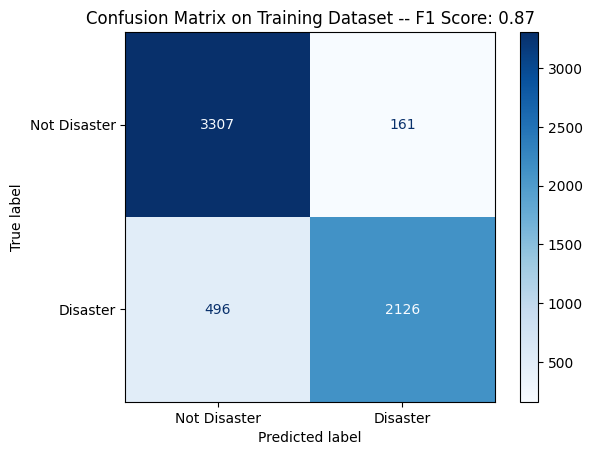

In [16]:
y_pred_train=classifier.predict(X_train)
displayConfusionMatrix(y_train,y_pred_train,"Training")

48/48 ━━━━━━━━━━━━━━━━━━━━ 10s 200ms/step


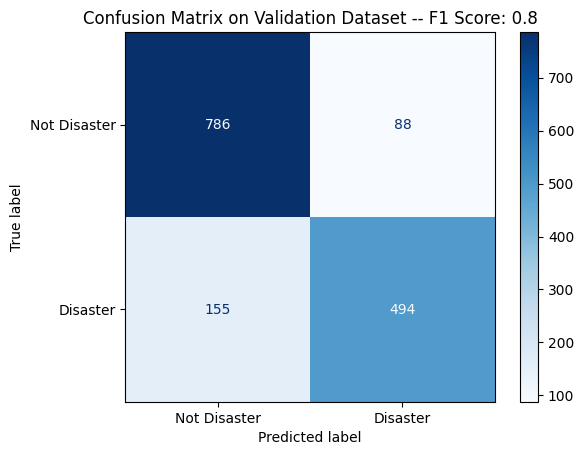

In [17]:
y_pred_val=classifier.predict(X_val)
displayConfusionMatrix(y_val,y_pred_val,"Validation")

## Generate the submission file

In [18]:
sample_submission=pd.read_csv("/content/drive/MyDrive/Colab/ESAA/sample_submission.csv")
sample_submission.head()

,id,target
0,0,0
1,2,0
2,3,0
3,9,0
4,11,0


In [19]:
sample_submission["target"]=np.argmax(classifier.predict(X_test),axis=1)

102/102 ━━━━━━━━━━━━━━━━━━━━ 20s 196ms/step


In [22]:
sample_submission.describe()

,id,target
count,3263.000000,3263.000000
mean,5427.152927,0.368066
std,3146.427221,0.482353
min,0.000000,0.000000
25%,2683.000000,0.000000
50%,5500.000000,0.000000
75%,8176.000000,1.000000
max,10875.000000,1.000000


In [23]:
sample_submission.to_csv("submission.csv",index=False)